In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from EMDPM.visualization import *
import os



paths = [ #"/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_1.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_2.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_3.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_4.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_5.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_6.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_7.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_8.npz",
        "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_9.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_10.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_11.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_12.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_13.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_14.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_15.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_16.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_17.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_18.npz",
        # "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/f_init_glm_eigen_meanK_alphakappatest_19.npz",
]


def load_results(paths):
    results = {}
    for path in paths:
        key = os.path.splitext(os.path.basename(path))[0]
        data = np.load(path, allow_pickle=True)
        results[key] = data
        print(f"Loaded {key} -> keys: {list(data.files)}")
    return results

results = load_results(paths)

# results[0]["lse_history"]
# results[3]["theta_history"]
n_biomarkers = 68
summary = []

for cand, data in results.items():
    final_theta = data["theta_history"][:,-1]
    print(cand,np.round(data["theta_history"][:,0][0:10], 4))
    final_f = final_theta[:n_biomarkers]
    final_s = final_theta[n_biomarkers:2*n_biomarkers]
    final_scalarK = final_theta[-1]
    final_cog = data["cog_history"][:,-1]
    final_lse = data["lse_history"][-1]

    summary.append({
        "candidate": cand,
        "final_lse": final_lse,
        "mean_f": final_f.mean(),
        "mean_s": final_s.mean(),
        "scalar_K": final_scalarK,
    })

summary_df = pd.DataFrame(summary).set_index("candidate")
summary_df

Loaded f_init_glm_eigen_meanK_alphakappatest_9 -> keys: ['theta_history', 'cog_history', 'beta_history', 'lse_history', 'beta_val', 'candidate', 'f_init']
f_init_glm_eigen_meanK_alphakappatest_9 [0.1055 0.1257 0.2925 0.0517 0.     0.1075 0.0587 0.1235 0.     0.0727]


,final_lse,mean_f,mean_s,scalar_K
candidate,,,,
f_init_glm_eigen_meanK_alphakappatest_9,547.471284,0.048504,0.762926,0.003405


In [13]:
biomarker_names = ['L_bankssts_thickavg', 'L_caudalanteriorcingulate_thickavg', 'L_caudalmiddlefrontal_thickavg', 'L_cuneus_thickavg',
                   'L_entorhinal_thickavg', 'L_fusiform_thickavg', 'L_inferiorparietal_thickavg', 'L_inferiortemporal_thickavg',
                   'L_isthmuscingulate_thickavg', 'L_lateraloccipital_thickavg', 'L_lateralorbitofrontal_thickavg',
                   'L_lingual_thickavg', 'L_medialorbitofrontal_thickavg', 'L_middletemporal_thickavg', 'L_parahippocampal_thickavg',
                   'L_paracentral_thickavg', 'L_parsopercularis_thickavg', 'L_parsorbitalis_thickavg', 'L_parstriangularis_thickavg',
                   'L_pericalcarine_thickavg', 'L_postcentral_thickavg', 'L_posteriorcingulate_thickavg', 'L_precentral_thickavg',
                   'L_precuneus_thickavg', 'L_rostralanteriorcingulate_thickavg', 'L_rostralmiddlefrontal_thickavg', 'L_superiorfrontal_thickavg',
                   'L_superiorparietal_thickavg', 'L_superiortemporal_thickavg', 'L_supramarginal_thickavg', 'L_frontalpole_thickavg',
                   'L_temporalpole_thickavg', 'L_transversetemporal_thickavg', 'L_insula_thickavg', 'R_bankssts_thickavg', 'R_caudalanteriorcingulate_thickavg',
                   'R_caudalmiddlefrontal_thickavg', 'R_cuneus_thickavg', 'R_entorhinal_thickavg', 'R_fusiform_thickavg', 'R_inferiorparietal_thickavg',
                   'R_inferiortemporal_thickavg', 'R_isthmuscingulate_thickavg', 'R_lateraloccipital_thickavg', 'R_lateralorbitofrontal_thickavg',
                   'R_lingual_thickavg', 'R_medialorbitofrontal_thickavg', 'R_middletemporal_thickavg', 'R_parahippocampal_thickavg', 'R_paracentral_thickavg',
                   'R_parsopercularis_thickavg', 'R_parsorbitalis_thickavg', 'R_parstriangularis_thickavg', 'R_pericalcarine_thickavg', 'R_postcentral_thickavg',
                   'R_posteriorcingulate_thickavg', 'R_precentral_thickavg', 'R_precuneus_thickavg', 'R_rostralanteriorcingulate_thickavg',
                   'R_rostralmiddlefrontal_thickavg', 'R_superiorfrontal_thickavg', 'R_superiorparietal_thickavg', 'R_superiortemporal_thickavg',
                   'R_supramarginal_thickavg', 'R_frontalpole_thickavg', 'R_temporalpole_thickavg', 'R_transversetemporal_thickavg', 'R_insula_thickavg']

ROI = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]
ROI_names = [biomarker_names[i] for i in ROI]

f_init_glm_eigen_meanK_alphakappatest_9 547.4712839800471


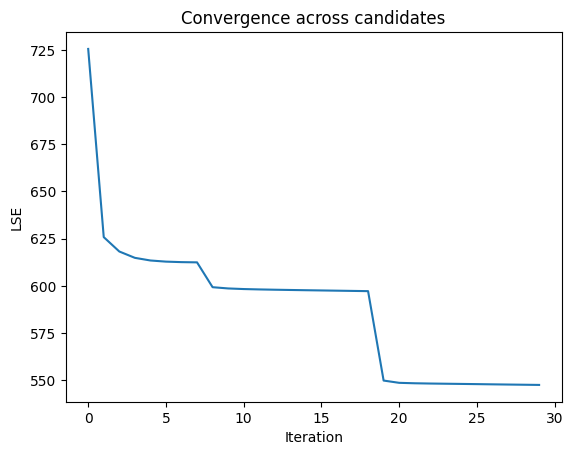

In [14]:
plt.figure()
for cand, data in results.items():
    plt.plot(data["lse_history"][1:], label=f"{cand}")
    print(cand, min(data["lse_history"][1:]))
plt.xlabel("Iteration")
plt.ylabel("LSE")
plt.title("Convergence across candidates")
plt.show()

In [15]:
from EMDPM.utils import solve_system

df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
df_K = pd.read_csv("/data01/bgutman/LEGACY/Skoltech/datasets/Connectomes/mean_NORM_con_22.csv")

## remove non-longitudinal observations
print("original size:", df.shape)
relevant_cols = [col for col in df.columns if col.startswith(('L_', 'R_')) and ('_thickavg' in col or '_thickavg_resid' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)

print("after drop na", df.shape)
subj_counts = df['subj_id'].value_counts()
num_unique = (subj_counts == 1).sum()
print("one time subj_id:", num_unique)

longitudinal_ids = subj_counts[subj_counts > 1].index
df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])
print("after drop dupes", df.shape)

X_obs = df[[col for col in df.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]

# X_obs = df[small_region_set]
X_obs = X_obs.to_numpy()
X_obs = np.max(X_obs, axis=0) - X_obs

print("nans in X:", np.isnan(X_obs).sum())
print("infs in X:", np.isinf(X_obs).sum())

## connectivity matrix to numpy
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)
print(K.shape, type(K))

# normalization
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum

t_max = 40
t_span = np.linspace(0, t_max, int(t_max/0.01))

df.head(4)


dt_all = (df["time"].to_numpy() / 12.0)              # years, (n_obs,)
ids_all = df["subj_id"].to_numpy()                   # (n_obs,)
nhy_all = df["NHY"].to_numpy()                       # (n_obs,)
cog_all = df[["MCATOT","TD_score","PIGD_score"]].to_numpy()  # (n_obs, 3)

print("ALL shapes:",
      "dt_all", dt_all.shape,
      "ids_all", ids_all.shape,
      "nhy_all", nhy_all.shape,
      "cog_all", cog_all.shape)


original size: (880, 250)
after drop na (868, 250)
one time subj_id: 227
after drop dupes (504, 250)
nans in X: 0
infs in X: 0
(68, 68) <class 'numpy.ndarray'>
ALL shapes: dt_all (504,) ids_all (504,) nhy_all (504,) cog_all (504, 3)


In [16]:
from sklearn.model_selection import train_test_split

def create_patient_list(X_obs, ids, dt, cog, nhy, initial_beta=None):
    unique_ids = np.unique(ids)
    id_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}

    patient_list = []
    for pid in unique_ids:
        mask = (ids == pid)
        patient_data = {
            "id": pid,
            "X_obs": X_obs[mask],
            "dt": dt[mask],
            "cog": cog[mask],
            "nhy": nhy[mask],
        }
        if initial_beta is not None:
            patient_data["initial_beta"] = initial_beta[id_to_index[pid]]
        patient_list.append(patient_data)

    return patient_list

# Build ALL patient list from already-filtered df and arrays:
X_all = create_patient_list(X_obs, ids_all, dt_all, cog_all, nhy_all)

X_train, X_val = train_test_split(X_all, test_size=0.2, random_state=75)
print("n_train:", len(X_train), "n_val:", len(X_val))

# Load one results file (or loop through your results dict)
# Example: data = results[some_key]
final_beta_train = data["beta_history"][:, -1]          # per-patient betas for TRAIN
beta_val_saved = data["beta_val"] if "beta_val" in data.files else None

# Map in the order EM used (the order of X_train list at fit time)
train_ids_order = [p["id"] for p in X_train]
if len(final_beta_train) != len(train_ids_order):
    raise ValueError(f"Train beta length {len(final_beta_train)} != train IDs {len(train_ids_order)}")

pid_to_beta = {pid: final_beta_train[i] for i, pid in enumerate(train_ids_order)}

# Add VAL betas if present
if beta_val_saved is not None:
    val_ids_order = [p["id"] for p in X_val]
    if len(beta_val_saved) != len(val_ids_order):
        raise ValueError(f"Val beta length {len(beta_val_saved)} != val IDs {len(val_ids_order)}")
    for i, pid in enumerate(val_ids_order):
        pid_to_beta[pid] = beta_val_saved[i]


beta_all = np.array([pid_to_beta.get(pid, np.nan) for pid in ids_all])
missing = np.isnan(beta_all).sum()



n_train: 116 n_val: 30


In [17]:

# X_train = np.load("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/X_train_68biom.npy", allow_pickle=True)
# X_val = np.load("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/X_val_68biom.npy", allow_pickle=True)

# print("shape X_train: ", X_train.shape, "shape X_val: ",X_val.shape)

# def unpack_patient_list(patient_list):
#     X_obs = []
#     dt = []
#     ids = []
#     cog = []
#     nhy = []
#     for patient in patient_list:
#         n_visits = patient["dt"].shape[0]
#         pid = patient["id"]
#         X_obs.append(patient["X_obs"])
#         dt.append(patient["dt"])
#         ids.append(np.full(n_visits, pid))
#         cog.append(patient["cog"])
#         nhy.append(patient["nhy"])
#     return (
#         np.vstack(X_obs),
#         np.concatenate(dt),
#         np.concatenate(ids),
#         np.vstack(cog),
#         np.concatenate(nhy),
#     )

# X_obs_val, dt_val, ids_val, cog_val, nhy_val = unpack_patient_list(X_val)
# X_obs_train, dt_train, ids_train, cog_train, nhy_train = unpack_patient_list(X_train)

# unique_ids = np.unique(ids_train)
# pid_to_beta = {pid: final_beta[i] for i, pid in enumerate(unique_ids)}
# beta_train = [pid_to_beta[pid] for pid in ids_train]



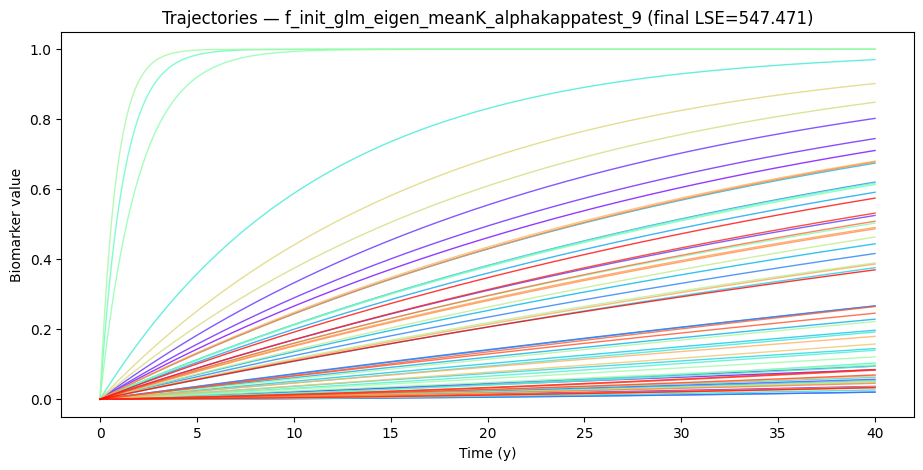

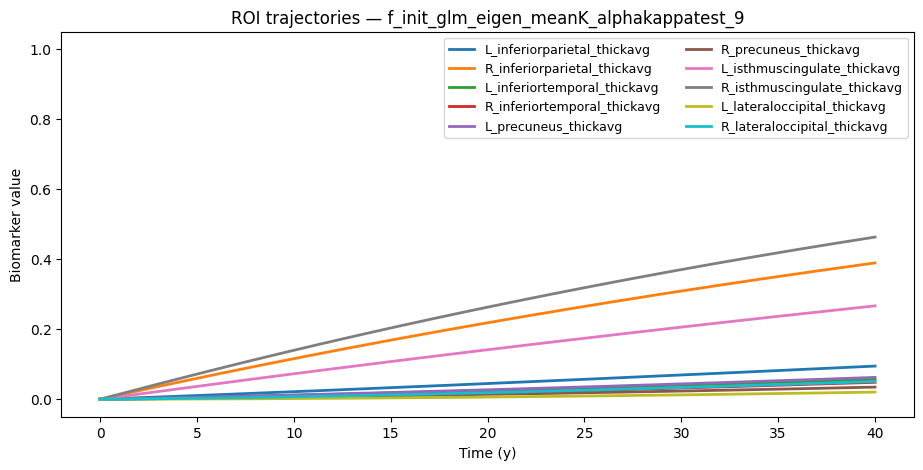

In [18]:
n_biomarkers = len(biomarker_names)

for key, data in results.items():
    # extract finals
    theta_hist = data["theta_history"]
    lse_hist = data["lse_history"]
    final_theta = theta_hist[:, -1]
    final_f = final_theta[:n_biomarkers]
    final_s_K = final_theta[-1]

    # solve complete model curves
    x0 = np.zeros(n_biomarkers)
    Xtraj = solve_system(x0, final_f, K, t_span, final_s_K)  # (n_biomarkers, len(t_span))

    # 1) all-biomarkers figure
    plt.figure(figsize=(11, 5))
    colors = plt.cm.rainbow(np.linspace(0, 1, n_biomarkers))
    for b in range(n_biomarkers):
        plt.plot(t_span, Xtraj[b], color=colors[b], alpha=0.8, linewidth=1.0)
    plt.ylim(-0.05, 1.05)
    plt.xlabel("Time (y)")
    plt.ylabel("Biomarker value")
    plt.title(f"Trajectories — {key} (final LSE={lse_hist[-1]:.3f})")
    plt.show()

    # 2) ROI-only figure
    plt.figure(figsize=(11, 5))
    tab10 = plt.cm.tab10.colors
    for i, b in enumerate(ROI):
        plt.plot(t_span, Xtraj[b], label=ROI_names[i], linewidth=2.0, color=tab10[i % 10])
    plt.ylim(-0.05, 1.05)
    plt.xlabel("Time (y)")
    plt.ylabel("Biomarker value")
    plt.title(f"ROI trajectories — {key}")
    plt.legend(ncol=2, fontsize=9)
    plt.show()


/home/dsemchin/Progression_models_simulations/EMDPM/visualization.py:352: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1200x700 with 0 Axes>

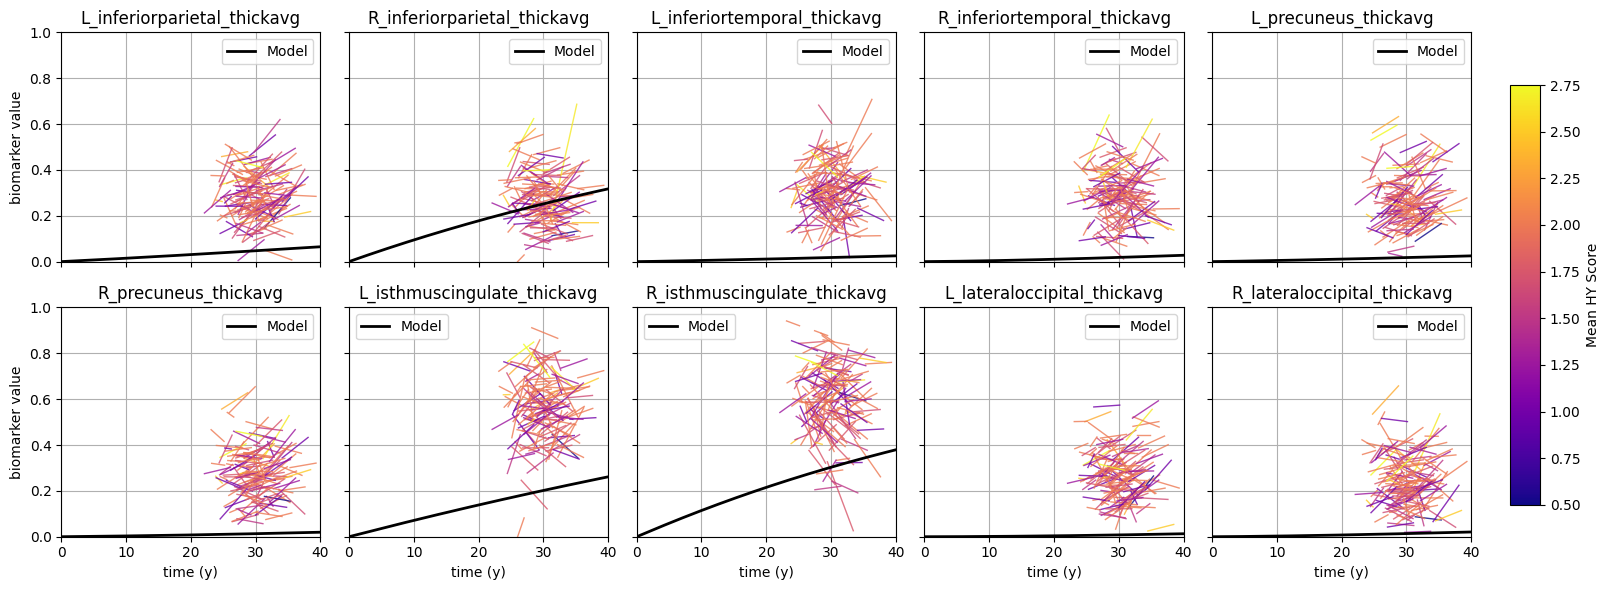

<Figure size 640x480 with 0 Axes>

In [19]:
from sklearn.model_selection import train_test_split

def build_pid_to_beta_from_results(ids_all, data, test_size=0.2, random_state=75):
    unique_ids_all = np.unique(ids_all)
    train_ids_order, val_ids_order = train_test_split(
        unique_ids_all, test_size=test_size, random_state=random_state
    )

    beta_train = data["beta_history"][:, -1]
    if beta_train.shape[0] != len(train_ids_order):
        raise ValueError(f"Train beta length {beta_train.shape[0]} != train_ids {len(train_ids_order)}")

    pid_to_beta = {pid: beta_train[i] for i, pid in enumerate(train_ids_order)}

    if "beta_val" in data.files:
        beta_val = data["beta_val"]
        if beta_val.shape[0] != len(val_ids_order):
            raise ValueError(f"Val beta length {beta_val.shape[0]} != val_ids {len(val_ids_order)}")
        for i, pid in enumerate(val_ids_order):
            pid_to_beta[pid] = beta_val[i]

    return pid_to_beta

def beta_vector_for_visits(ids_all, pid_to_beta, fill=np.nan):
    """Expand patient betas to per-visit vector aligned with ids_all."""
    return np.array([pid_to_beta.get(pid, fill) for pid in ids_all])

n_biomarkers = len(biomarker_names)

for key, data in results.items():
    # final theta -> f, s, scalar_K
    theta_hist = data["theta_history"]
    lse_hist   = data["lse_history"]
    final_theta = theta_hist[:, -1]
    final_f     = final_theta[:n_biomarkers]
    final_s     = final_theta[n_biomarkers:2*n_biomarkers]
    final_sK    = final_theta[-1]

    x0 = np.zeros(n_biomarkers)
    Xtraj = solve_system(x0, final_f, K, t_span, final_sK) * final_s[:, None]

    # map per-patient betas -> per-visit vector
    pid_to_beta = build_pid_to_beta_from_results(ids_all, data, test_size=0.2, random_state=75)
    beta_all = beta_vector_for_visits(ids_all, pid_to_beta)

    plt.figure(figsize=(12, 7))
    plot_all_patient_regression_lines_grid_nhy(
        X=X_obs,                
        dt=dt_all,
        ids=ids_all,
        beta=beta_all,
        t_span=t_span,
        nhy=nhy_all,
        model=Xtraj,
        biomarker_indices=ROI,
        biomarker_labels=biomarker_names,
        max_lines=500,
        t_max=t_span[-1]
    )
    plt.suptitle(f"{key} — final LSE: {lse_hist[-1]:.3f}", y=1.02)
    plt.show()


In [20]:
# plot_violin_nhy_vs_tij(dt=dt_val, ids=ids_val, beta=beta_val, nhy=nhy_val)
# plot_violin_nhy_vs_tij(dt=dt_train, ids=ids_train, beta=beta_train, nhy=nhy_train)
# plot_violin_nhy_vs_beta(dt=dt_val, ids=ids_val, beta=beta_val, nhy=nhy_val)
# plot_violin_nhy_vs_beta(dt=dt_train, ids=ids_train, beta=beta_train, nhy=nhy_train)


=== Violin plots for run: f_init_glm_eigen_meanK_alphakappatest_9 ===


/tmp/ipykernel_19252/1868256539.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="NHY", y="beta", palette="plasma", inner="box")


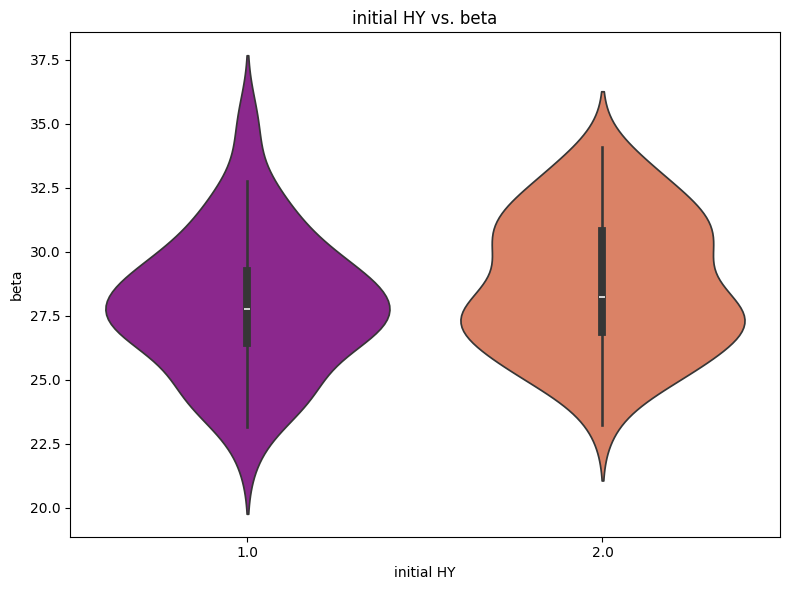

/tmp/ipykernel_19252/1868256539.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="NHY", y="t_ij", palette="plasma", inner="box")


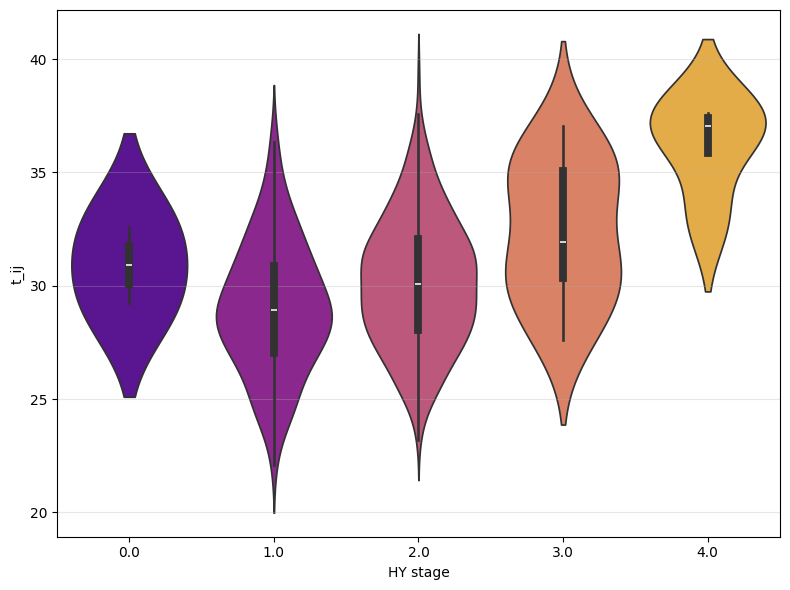

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# --- your original plotting helpers (unchanged) ---
def plot_violin_nhy_vs_beta(ids, dt, nhy, beta):
    unique_ids = np.unique(ids)
    pair = []
    pid_to_beta = {pid: beta[i] for i, pid in enumerate(unique_ids)}
    for pid in unique_ids:
        mask = (ids == pid)
        dt_i = dt[mask]
        nhy_i = nhy[mask]
        idx_min_dt = np.argmin(dt_i)
        nhy_first = nhy_i[idx_min_dt]
        beta_i = pid_to_beta.get(pid, np.nan)
        pair.append({"NHY": nhy_first, "beta": beta_i})
    df = pd.DataFrame(pair).dropna()
    plt.figure(figsize=(8, 6))
    sns.violinplot(data=df, x="NHY", y="beta", palette="plasma", inner="box")
    plt.title("initial HY vs. beta")
    plt.xlabel("initial HY")
    plt.ylabel("beta")
    plt.tight_layout()
    plt.show()

def plot_violin_nhy_vs_tij(dt, ids, beta, nhy):
    unique_ids = np.unique(ids)
    pid_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}
    # guard against missing betas -> NaN
    betas_by_pid = np.array([beta[pid_to_index[pid]] if pid in pid_to_index and pid_to_index[pid] < len(beta) else np.nan
                             for pid in ids])
    t_ij = dt + betas_by_pid
    df = pd.DataFrame({"t_ij": t_ij, "NHY": nhy}).dropna()
    plt.figure(figsize=(8, 6))
    sns.violinplot(data=df, x="NHY", y="t_ij", palette="plasma", inner="box")
    plt.xlabel("HY stage")
    plt.ylabel("t_ij")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def get_beta_per_patient(ids_all, data, test_size=0.2, random_state=75):
    unique_ids = np.unique(ids_all)

    # Use saved train/val id order if present
    if "train_ids" in data.files and "val_ids" in data.files:
        train_ids = np.array(list(data["train_ids"]))
        val_ids   = np.array(list(data["val_ids"]))
        beta_tr   = data["beta_history"][:, -1]
        pid_to_beta = {pid: beta_tr[i] for i, pid in enumerate(train_ids)}
        if "beta_val" in data.files:
            beta_val = data["beta_val"]
            for i, pid in enumerate(val_ids):
                pid_to_beta[pid] = beta_val[i]
        # align to unique_ids order
        beta_pp = np.array([pid_to_beta.get(pid, np.nan) for pid in unique_ids], dtype=float)
        return beta_pp

    # Try to reconstruct split
    try:
        train_ids_order, val_ids_order = train_test_split(unique_ids, test_size=test_size, random_state=random_state)
        pid_to_beta = {}
        if "beta_history" in data.files:
            bt = data["beta_history"][:, -1]
            for i, pid in enumerate(train_ids_order[:len(bt)]):
                pid_to_beta[pid] = bt[i]
        if "beta_val" in data.files:
            bv = data["beta_val"]
            for i, pid in enumerate(val_ids_order[:len(bv)]):
                pid_to_beta[pid] = bv[i]
        beta_pp = np.array([pid_to_beta.get(pid, np.nan) for pid in unique_ids], dtype=float)
        return beta_pp
    except Exception:
        pass

    # Last resort: fill NaNs (plots will drop them)
    return np.full(len(unique_ids), np.nan, dtype=float)

for key, data in results.items():
    print(f"\n=== Violin plots for run: {key} ===")
    beta_per_patient = get_beta_per_patient(ids_all, data)  # aligned to np.unique(ids_all)
    plot_violin_nhy_vs_beta(ids=ids_all, dt=dt_all, nhy=nhy_all, beta=beta_per_patient)
    plot_violin_nhy_vs_tij(dt=dt_all, ids=ids_all, beta=beta_per_patient, nhy=nhy_all)


In [22]:
from scipy.stats import spearmanr, kendalltau
unique_ids_val = np.unique(ids_val)
pid_to_beta_val = {pid: beta_val[i] for i, pid in enumerate(unique_ids_val)}
beta_val_full = [pid_to_beta_val[pid] for pid in ids_val]


print(spearmanr(beta_val_full+dt_val, nhy_val))
print(kendalltau(beta_val_full+dt_val, nhy_val))

print(spearmanr(beta_train+ dt_train, nhy_train))
print(kendalltau(beta_train + dt_train, nhy_train))

# print(nhy_val.shape, beta_val.shape)
# print(nhy_train.shape, np.array(beta_train).shape)




NameError: name 'ids_val' is not defined

In [ ]:
X_train_nsd = np.load("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/X_train_68biom_wNSD.npy", allow_pickle=True)
X_val_nsd = np.load("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/X_val_68biom_wNSD.npy", allow_pickle=True)

print("shape X_train: ", X_train.shape, "shape X_val: ", X_val.shape)
print("shape X_train: ", X_train_nsd.shape, "shape X_val: ", X_val_nsd.shape)

def unpack_patient_list(patient_list):
    X_obs = []
    dt = []
    ids = []
    cog = []
    nhy = []
    nsd = []
    for patient in patient_list:
        n_visits = patient["dt"].shape[0]
        pid = patient["id"]
        X_obs.append(patient["X_obs"])
        dt.append(patient["dt"])
        ids.append(np.full(n_visits, pid))
        cog.append(patient["cog"])
        nhy.append(patient["nhy"])
        nsd.append(patient["nsd"])
    return (
        np.vstack(X_obs),
        np.concatenate(dt),
        np.concatenate(ids),
        np.vstack(cog),
        np.concatenate(nhy),
        np.concatenate(nsd)
    )

X_obs_val_nsd, dt_val_nsd, ids_val_nsd, cog_val_nsd, nhy_val_nsd, nsd_val = unpack_patient_list(X_val_nsd)
X_obs_train_nsd, dt_train_nsd, ids_train_nsd, cog_train_nsd, nhy_train_nsd, nsd_train = unpack_patient_list(X_train_nsd)

AttributeError: 'list' object has no attribute 'shape'

/tmp/ipykernel_26068/2628088209.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="NHY", y="t_ij", palette="plasma", inner="box")


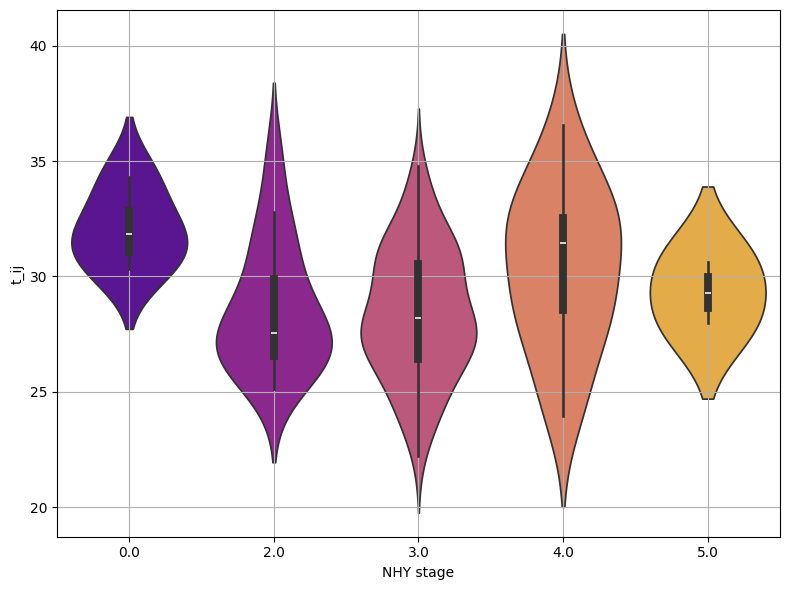

/tmp/ipykernel_26068/2628088209.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="NHY", y="t_ij", palette="plasma", inner="box")


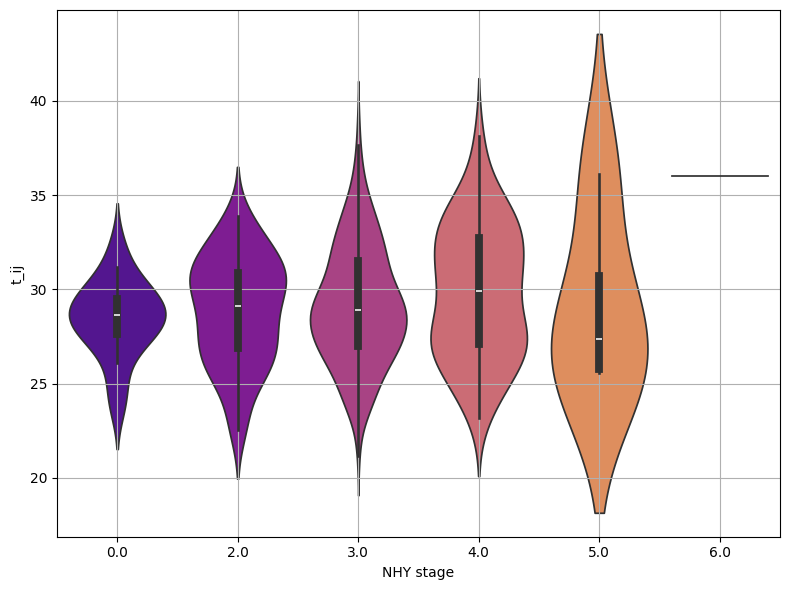

In [ ]:
plot_violin_nhy_vs_tij(dt=dt_val, ids=ids_val, beta=beta_val, nhy=nsd_val)
plot_violin_nhy_vs_tij(dt=dt_train, ids=ids_train, beta=final_beta, nhy=nsd_train)

/tmp/ipykernel_26068/1121853890.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="NHY", y="beta", palette="plasma", inner="box")


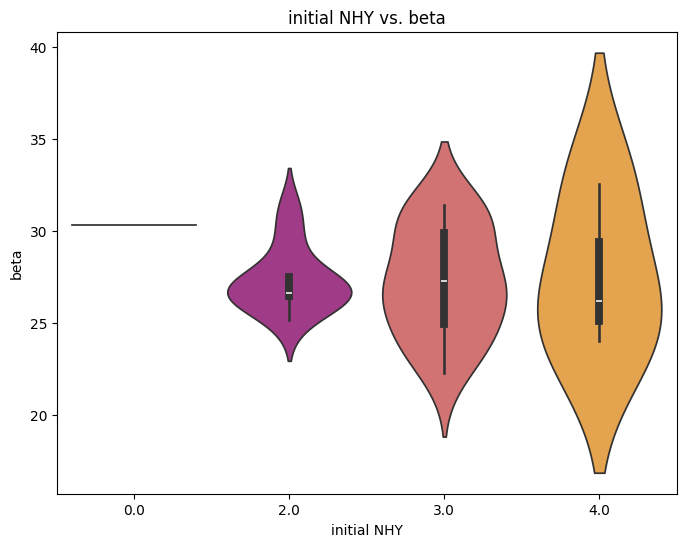

/tmp/ipykernel_26068/1121853890.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="NHY", y="beta", palette="plasma", inner="box")


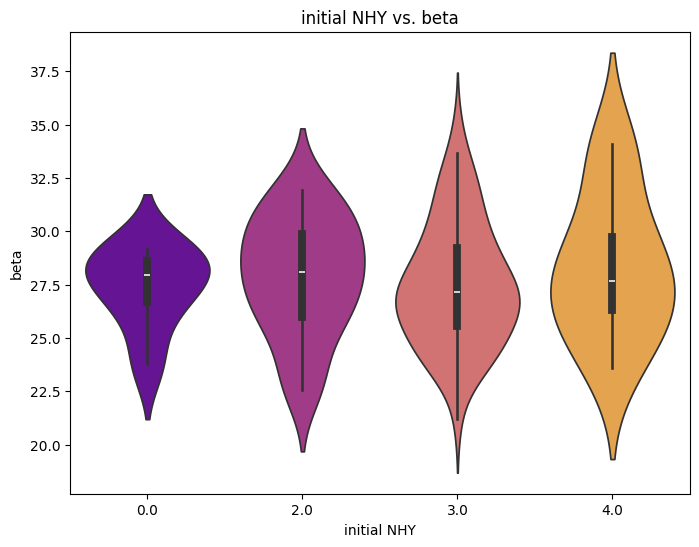

In [ ]:
plot_violin_nhy_vs_beta(dt=dt_val, ids=ids_val, beta=beta_val, nhy=nsd_val)
plot_violin_nhy_vs_beta(dt=dt_train, ids=ids_train, beta=final_beta, nhy=nsd_train)